# Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf  # Ensure TensorFlow is imported

from tensorflow.keras import layers, Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization,
    Activation, MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D,
    GlobalMaxPooling2D, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings  # Ensure warnings is imported

# Configurations and Initializations
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
warnings.filterwarnings('ignore')
SEED = 123
np.random.seed(SEED)

# GPU Configuration
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("RuntimeError in setting memory growth:", e)



In [ ]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam # - Works
import random
from glob import glob
import seaborn as sns
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import matplotlib.pyplot as plt
import matplotlib.image as img
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print(gpus)
try:
    tf.config.experimental.set_memory_growth = True
except Exception as ex:
    print(e)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Prepare dataset


In [ ]:
! rm -rf /kaggle/working/data/

In [ ]:
data_dir_train = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/")
data_dir_test = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test/")

In [ ]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


In [ ]:
batch_size = 32
img_height = 180
img_width = 180
rnd_seed = 123
random.seed(rnd_seed)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_test,
  validation_split=0.9,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.
Found 2239 files belonging to 9 classes.
Using 447 files for validation.
Found 118 files belonging to 9 classes.
Using 106 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical",
                                                 input_shape=(img_height,
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
  ]
)

total training image count = 2239 

-------------------------------------
Class name =  actinic keratosis
count      =  114
proportion =  0.05091558731576597
-------------------------------------
Class name =  basal cell carcinoma
count      =  376
proportion =  0.16793211255024565
-------------------------------------
Class name =  dermatofibroma
count      =  95
proportion =  0.04242965609647164
-------------------------------------
Class name =  melanoma
count      =  438
proportion =  0.19562304600267977
-------------------------------------
Class name =  nevus
count      =  357
proportion =  0.15944618133095131
-------------------------------------
Class name =  pigmented benign keratosis
count      =  462
proportion =  0.20634211701652524
-------------------------------------
Class name =  seborrheic keratosis
count      =  77
proportion =  0.03439035283608754
-------------------------------------
Class name =  squamous cell carcinoma
count      =  181
proportion =  0.08083966056

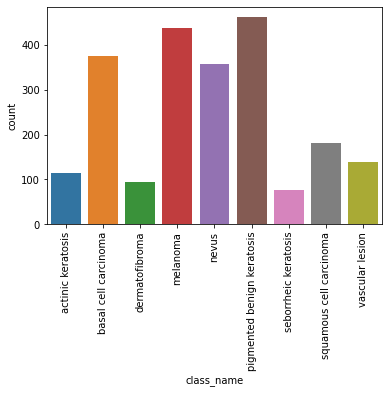

In [ ]:
num_classes = len(class_names)
total = 0
all_count = []
class_name = []
for i in range(num_classes):
  count = len(list(data_dir_train.glob(class_names[i]+'/*.jpg')))
  total += count
print("total training image count = {} \n".format(total))
print("-------------------------------------")
for i in range(num_classes):
  count = len(list(data_dir_train.glob(class_names[i]+'/*.jpg')))
  print("Class name = ",class_names[i])
  print("count      = ",count)
  print("proportion = ",count/total)
  print("-------------------------------------")
  all_count.append(count)
  class_name.append(class_names[i])

temp_df = pd.DataFrame(list(zip(all_count, class_name)), columns = ['count', 'class_name'])
sns.barplot(data=temp_df, y="count", x="class_name")
plt.xticks(rotation=90)
plt.show()

## Augmentor : Class balance

In [ ]:
!pip install Augmentor

In [ ]:
path_to_training_dataset = '../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/'
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i, output_directory='/kaggle/working/data/'+i+'/output/')
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(1000)

Initialised with 114 image(s) found.
Output directory set to /kaggle/working/data/actinic keratosis/output/.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A9B498C5E90>: 100%|██████████| 1000/1000 [00:16<00:00, 61.65 Samples/s]                  


Initialised with 376 image(s) found.
Output directory set to /kaggle/working/data/basal cell carcinoma/output/.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7A9B499A9210>: 100%|██████████| 1000/1000 [00:15<00:00, 64.20 Samples/s]


Initialised with 95 image(s) found.
Output directory set to /kaggle/working/data/dermatofibroma/output/.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7A9B4A02F710>: 100%|██████████| 1000/1000 [00:39<00:00, 25.53 Samples/s]                 


Initialised with 181 image(s) found.
Output directory set to /kaggle/working/data/squamous cell carcinoma/output/.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7A9B499BB190>: 100%|██████████| 1000/1000 [00:15<00:00, 64.79 Samples/s]


Initialised with 139 image(s) found.
Output directory set to /kaggle/working/data/vascular lesion/output/.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A9B54ADE250>: 100%|██████████| 1000/1000 [00:16<00:00, 61.33 Samples/s]                  


In [ ]:
output_dir = pathlib.Path('/kaggle/working/data/')
image_count_train = len(list(output_dir.glob('*/output/*.jpg')))
print(image_count_train)

9000


total training image count = 9000 

-------------------------------------
Class name =  actinic keratosis
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  basal cell carcinoma
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  dermatofibroma
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  melanoma
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  nevus
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  pigmented benign keratosis
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  seborrheic keratosis
count      =  1000
proportion =  0.1111111111111111
-------------------------------------
Class name =  squamous cell carcinoma
count      =  1000
proportion =  0.11111111

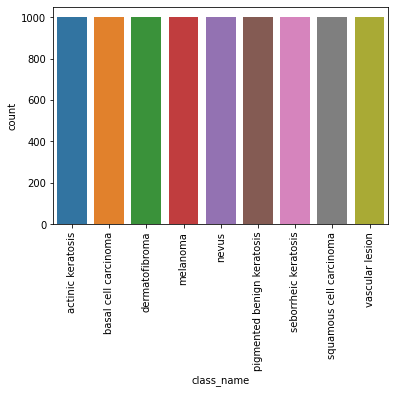

In [ ]:
num_classes = len(class_names)
total = 0
all_count = []
class_name = []

for i in range(num_classes):
  count = len(list(output_dir.glob(class_names[i]+'/output/*.jpg')))
  total += count
print("total training image count = {} \n".format(total))
print("-------------------------------------")
for i in range(num_classes):
  count = len(list(output_dir.glob(class_names[i]+'/output/*.jpg')))
  print("Class name = ",class_names[i])
  print("count      = ",count)
  print("proportion = ",count/total)
  print("-------------------------------------")
  all_count.append(count)
  class_name.append(class_names[i])


temp_df = pd.DataFrame(list(zip(all_count, class_name)), columns = ['count', 'class_name'])
sns.barplot(data=temp_df, y="count", x="class_name")
plt.xticks(rotation=90)
plt.show()

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  output_dir,
  seed=123,
  validation_split = 0.2,
  subset = 'training',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 9000 files belonging to 9 classes.
Using 7200 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  output_dir,
  seed=123,
  validation_split = 0.2,
  subset = 'validation',
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 9000 files belonging to 9 classes.
Using 1800 files for validation.


## 1. InceptionResNetV2 model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
import tensorflow_addons as tfa

# Define the number of classes
num_classes = 9
img_height = 180
img_width = 180

# Load the InceptionResNetV2 model, pre-trained on ImageNet data
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add data augmentation
data_augmentation = Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

# Create the model
model2 = Sequential([
    # Preprocessing layer
    data_augmentation,
    layers.experimental.preprocessing.Rescaling(1.0/255),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1024, activation='relu'),
    Dense(num_classes, activation='softmax')
])

opt = tfa.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

# Compile the model
model2.compile(optimizer=opt,
               loss=SparseCategoricalCrossentropy(),
               metrics=['accuracy'])

# Train the model
epochs = 50
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# Fine-tuning
# Unfreeze the base model
base_model.trainable = True

# You might want to experiment with which layers to freeze/unfreeze
for layer in base_model.layers[:100]:  # Fine-tune from this layer onwards
    layer.trainable = False

# Compile the model with a lower learning rate
model2.compile(optimizer=tfa.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
               loss=SparseCategoricalCrossentropy(),
               metrics=['accuracy'])




219070464/219055592 [==============================] - 1s 0us/step
Epoch 1/50
225/225 [==============================] - 54s 178ms/step - loss: 1.6724 - accuracy: 0.4183 - val_loss: 1.3202 - val_accuracy: 0.5078
Epoch 2/50
225/225 [==============================] - 37s 160ms/step - loss: 1.3156 - accuracy: 0.5296 - val_loss: 1.3102 - val_accuracy: 0.5044
Epoch 3/50
225/225 [==============================] - 37s 161ms/step - loss: 1.2091 - accuracy: 0.5579 - val_loss: 1.1518 - val_accuracy: 0.5628
Epoch 4/50
225/225 [==============================] - 37s 163ms/step - loss: 1.1267 - accuracy: 0.5863 - val_loss: 1.0817 - val_accuracy: 0.6006
Epoch 5/50
225/225 [==============================] - 37s 163ms/step - loss: 1.0766 - accuracy: 0.6062 - val_loss: 1.0772 - val_accuracy: 0.6039
Epoch 6/50
225/225 [==============================] - 37s 163ms/step - loss: 1.0075 - accuracy: 0.6242 - val_loss: 0.9715 - val_accuracy: 0.6383
Epoch 7/50
225/225 [==============================] - 37s 163ms

In [ ]:
# Continue training for more epochs
fine_tune_epochs = 50
total_epochs = epochs + fine_tune_epochs

history_fine = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history2.epoch[-1]
)

Epoch 50/100
225/225 [==============================] - 116s 413ms/step - loss: 1.9089 - accuracy: 0.3007 - val_loss: 1.4590 - val_accuracy: 0.4828
Epoch 51/100
225/225 [==============================] - 89s 394ms/step - loss: 1.3939 - accuracy: 0.4981 - val_loss: 1.1786 - val_accuracy: 0.5856
Epoch 52/100
225/225 [==============================] - 89s 393ms/step - loss: 1.0856 - accuracy: 0.6001 - val_loss: 0.9466 - val_accuracy: 0.6556
Epoch 53/100
225/225 [==============================] - 89s 393ms/step - loss: 0.8979 - accuracy: 0.6696 - val_loss: 0.7913 - val_accuracy: 0.6950
Epoch 54/100
225/225 [==============================] - 89s 393ms/step - loss: 0.7348 - accuracy: 0.7257 - val_loss: 0.6672 - val_accuracy: 0.7483
Epoch 55/100
225/225 [==============================] - 89s 394ms/step - loss: 0.6374 - accuracy: 0.7650 - val_loss: 0.5743 - val_accuracy: 0.7872
Epoch 56/100
225/225 [==============================] - 88s 389ms/step - loss: 0.5344 - accuracy: 0.8018 - val_loss: 

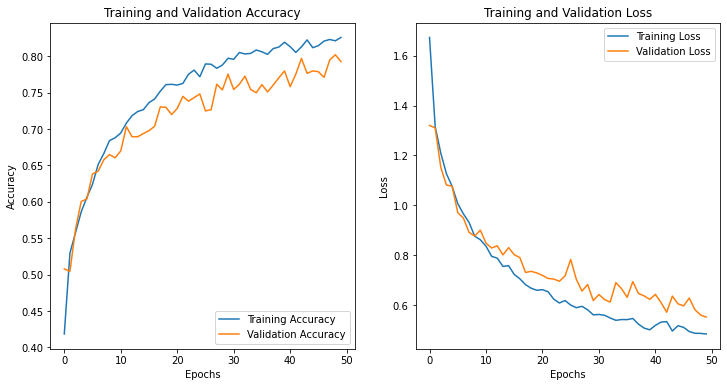

In [ ]:
import matplotlib.pyplot as plt

# Plot the training and validation accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot the training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()



## 2. ResNet101V2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet101V2
import tensorflow_addons as tfa
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Define the number of classes, image height and width
num_classes = 9
img_height = 180
img_width = 180

# Load the ResNet152 model pre-trained on ImageNet data
base_model = ResNet101V2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Enhanced data augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

# Create the model
model3 = Sequential([
    data_augmentation,
    layers.Rescaling(1.0/255),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model with initial settings
opt = tfa.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
model3.compile(optimizer=opt,
               loss=SparseCategoricalCrossentropy(),
               metrics=['accuracy'])

# Train the model initially with frozen ResNet152 layers
epochs = 50
history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# Fine-tuning: Unfreeze some or all of the layers in the base model
base_model.trainable = True

# It's often beneficial to fine-tune only the top layers of the base model initially
# and gradually include more layers. Here, we choose to train the top 50 layers.
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Re-compile the model for fine-tuning with a lower learning rate
model3.compile(optimizer=tfa.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
               loss=SparseCategoricalCrossentropy(),
               metrics=['accuracy'])

# Continue training the model for fine-tuning
fine_tune_epochs = 35
total_epochs = epochs + fine_tune_epochs

history_fine3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history3.epoch[-1]
)


171327488/171317808 [==============================] - 1s 0us/step
Epoch 1/50
225/225 [==============================] - 46s 160ms/step - loss: 1.6646 - accuracy: 0.4035 - val_loss: 1.4077 - val_accuracy: 0.4750
Epoch 2/50
225/225 [==============================] - 35s 151ms/step - loss: 1.3760 - accuracy: 0.4992 - val_loss: 1.2075 - val_accuracy: 0.5606
Epoch 3/50
225/225 [==============================] - 35s 154ms/step - loss: 1.2917 - accuracy: 0.5243 - val_loss: 1.1589 - val_accuracy: 0.5628
Epoch 4/50
225/225 [==============================] - 36s 156ms/step - loss: 1.2357 - accuracy: 0.5478 - val_loss: 1.1974 - val_accuracy: 0.5361
Epoch 5/50
225/225 [==============================] - 36s 157ms/step - loss: 1.1739 - accuracy: 0.5767 - val_loss: 1.1081 - val_accuracy: 0.5778
Epoch 6/50
225/225 [==============================] - 36s 159ms/step - loss: 1.1631 - accuracy: 0.5763 - val_loss: 1.0648 - val_accuracy: 0.6011
Epoch 7/50
225/225 [==============================] - 37s 160ms

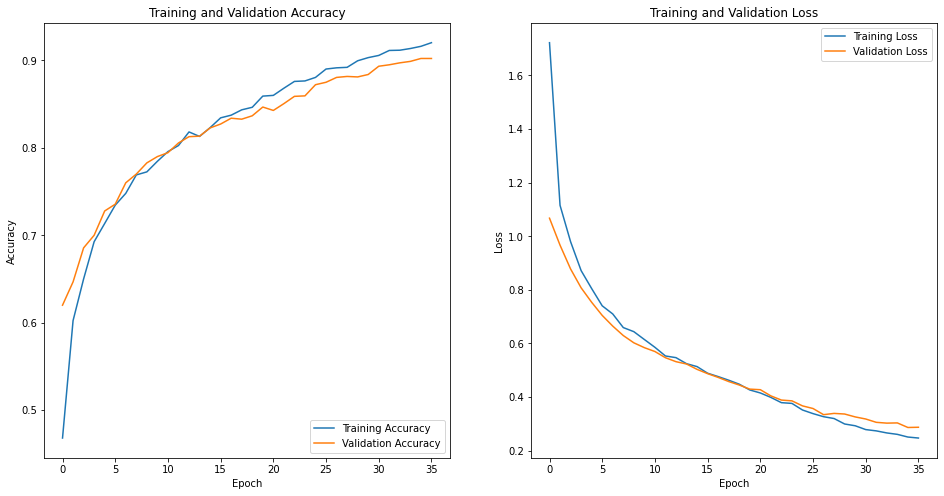

In [ ]:
import matplotlib.pyplot as plt

def plot_fine_tuning_history(history_fine):
    # Extract the accuracy and loss for training and validation sets
    acc = history_fine.history['accuracy']
    val_acc = history_fine.history['val_accuracy']
    loss = history_fine.history['loss']
    val_loss = history_fine.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 8))

    # Plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.show()

# Use the function with the fine-tuning history object
plot_fine_tuning_history(history_fine3)


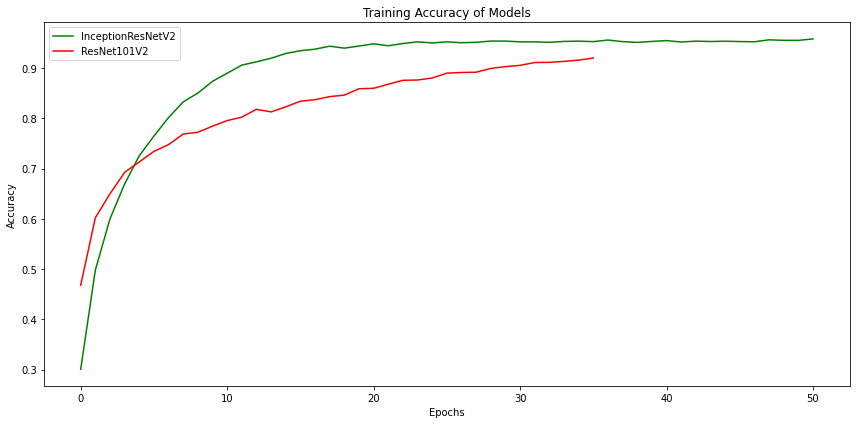

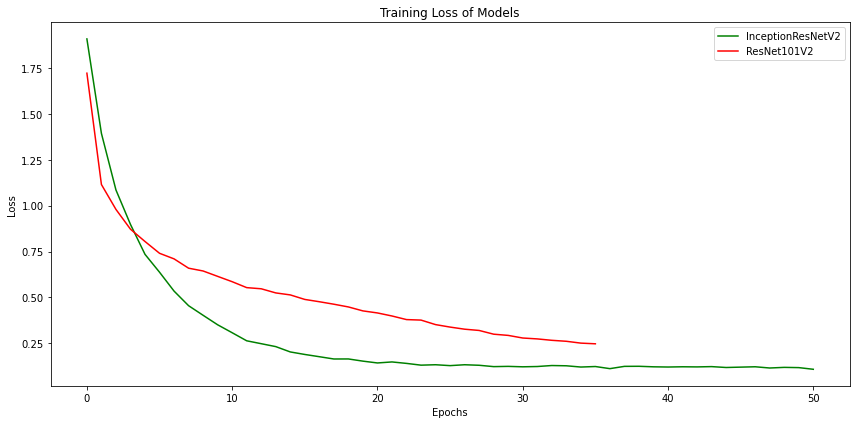

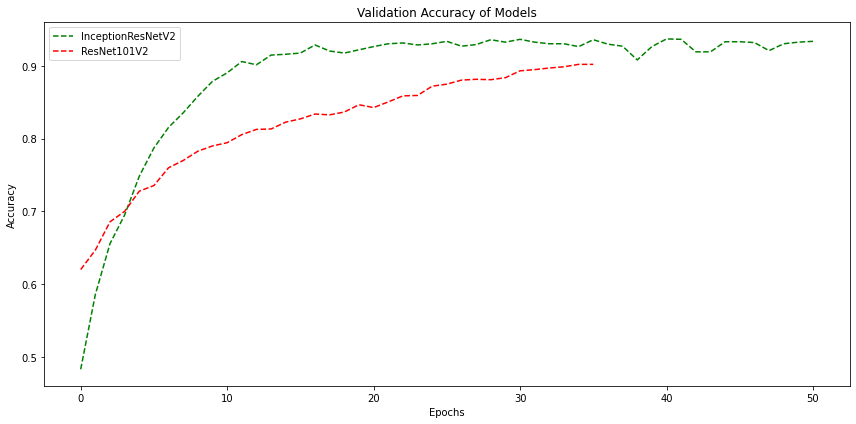

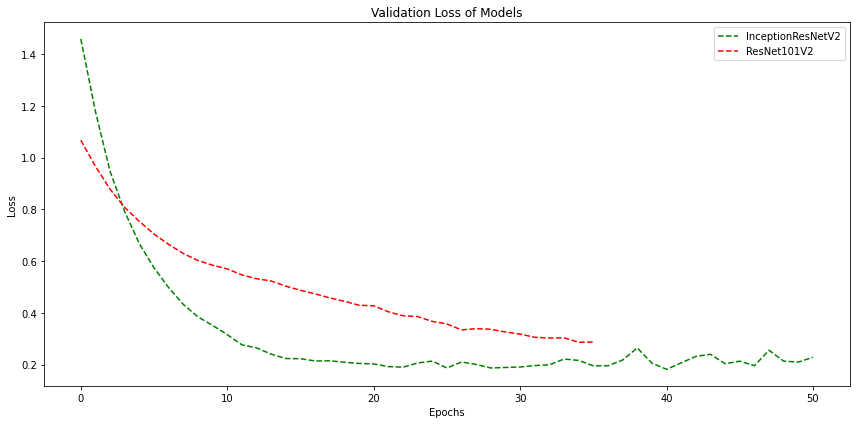

In [ ]:
import matplotlib.pyplot as plt

# Training Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_fine.history['accuracy'], label='InceptionResNetV2', color='green')
plt.plot(history_fine3.history['accuracy'], label='ResNet101V2', color='red')
plt.title('Training Accuracy of Models')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Training Loss
plt.figure(figsize=(12, 6))
plt.plot(history_fine.history['loss'], label='InceptionResNetV2', color='green')
plt.plot(history_fine3.history['loss'], label='ResNet101V2', color='red')
plt.title('Training Loss of Models')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_fine.history['val_accuracy'], label='InceptionResNetV2', color='green', linestyle='dashed')
plt.plot(history_fine3.history['val_accuracy'], label='ResNet101V2', color='red', linestyle='dashed')
plt.title('Validation Accuracy of Models')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history_fine.history['val_loss'], label='InceptionResNetV2', color='green', linestyle='dashed')
plt.plot(history_fine3.history['val_loss'], label='ResNet101V2', color='red', linestyle='dashed')
plt.title('Validation Loss of Models')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()



## 5 Preprocessing



In [ ]:
# Assume predict function returns the model's predictions for the given dataset
def train(model, dataset):
    # Ensure the dataset is batched appropriately
    predictions = model.predict(dataset)
    return predictions

# Generate predictions for each model
train_model = train(model, train_ds)  # Replace 'model' with your actual model variable
train_model2 = train(model2, train_ds)
train_model3 = train(model3, train_ds)

# Create a DataFrame for the meta-learner's training data
import pandas as pd

Metainput_train2 = pd.DataFrame({
    'Custom_model_pred': train_model.ravel(),
    'model2_pred': train_model2.ravel(),
    'model3_pred': train_model3.ravel()
})

# Now Metainput_train2 contains the predictions from your three models
# which will be used as features for training the meta-learner

Metainput_train2.tail()


,Custom_model_pred,model2_pred,model3_pred
64795,0.111120,0.000061,0.025841
64796,0.112497,0.999780,0.000818
64797,0.112162,0.000009,0.017578
64798,0.110098,0.000006,0.000170
64799,0.113355,0.000004,0.000060


In [ ]:
# Assume predict function returns the model's predictions for the given dataset
def test(model, dataset):
    # Ensure the dataset is batched appropriately
    predictions = model.predict(dataset)
    return predictions

# Generate predictions for each model
test_model = test(model, test_ds)  # Replace 'model' with your actual model variable
test_model2 = test(model2, test_ds)
test_model3 = test(model3, test_ds)

# Create a DataFrame for the meta-learner's training data
import pandas as pd

Metainput_test2 = pd.DataFrame({
    'Custom_model_pred': test_model.ravel(),
    'model2_pred': test_model2.ravel(),
    'model3_pred': test_model3.ravel()
})

# Now Metainput_train2 contains the predictions from your three models
# which will be used as features for training the meta-learner

Metainput_test2.tail()


,Custom_model_pred,model2_pred,model3_pred
949,0.111120,0.891165,0.045312
950,0.112497,0.000152,0.058809
951,0.112162,0.000088,0.010194
952,0.110098,0.000109,0.184947
953,0.113355,0.000335,0.004336


## 5.1 LogisticRegression


In [ ]:
# Assuming you use the predictions as both features and pseudo-labels
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Generate pseudo-labels based on the highest prediction score across models
pseudo_labels = np.argmax(Metainput_train2.values, axis=1)

# Initialize the meta-learner model
meta_learner = LogisticRegression()

# Train the meta-learner using the predictions as features and the pseudo-labels as targets
meta_learner.fit(Metainput_train2, pseudo_labels)

# Evaluate the meta-learner on some metric, perhaps through cross-validation or on a separate validation set

test_pseudo_labels = np.argmax(Metainput_test2.values, axis=1)

# Evaluate the meta-learner on the test data
test_predictions = meta_learner.predict(Metainput_test2)

# Calculate accuracy or other metrics to evaluate performance
accuracy = accuracy_score(test_pseudo_labels, test_predictions)
print(f"Meta-learner accuracy on test data: {accuracy}")


Meta-learner accuracy on test data: 0.9832285115303984


## 5.2 RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

# Train the RandomForestClassifier
random_forest_model.fit(Metainput_train2, pseudo_labels)

# Make predictions on the test set
test_predictions = random_forest_model.predict(Metainput_test2)

test_labels = np.argmax(Metainput_test2.values, axis=1)


# Evaluate the model's performance
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test accuracy: {test_accuracy}")


Test accuracy: 0.9989517819706499


## 5.3 DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(Metainput_train2, pseudo_labels)

# Generate predictions on the test set
dt_test_predictions = decision_tree_model.predict(Metainput_test2)

# Assuming you have pseudo labels for your test set
test_pseudo_labels = np.argmax(Metainput_test2.values, axis=1)

# Evaluate the model's performance
dt_test_accuracy = accuracy_score(test_pseudo_labels, dt_test_predictions)
print(f"Decision Tree test accuracy: {dt_test_accuracy}")


Decision Tree test accuracy: 0.9979035639412998


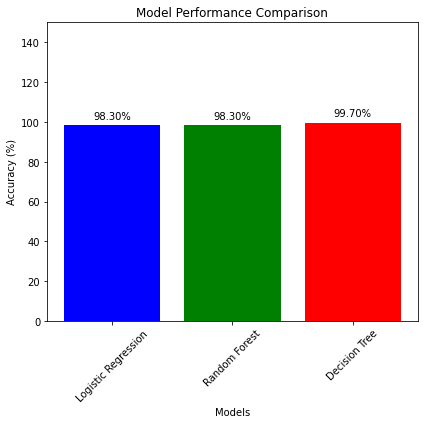

In [ ]:
import matplotlib.pyplot as plt

# Assuming these variables are defined
accuracy =0.983  # Logistic Regression accuracy
test_accuracy = 0.983 # Random Forest accuracy
dt_test_accuracy = 0.997  # Decision Tree accuracy

# Model names
models = ['Logistic Regression', 'Random Forest', 'Decision Tree']

# Corresponding accuracies
accuracies = [accuracy * 100, test_accuracy * 100, dt_test_accuracy * 100]

# Colors for each bar
colors = ['blue', 'green', 'red']

plt.figure(figsize=(6, 6))

bars = plt.bar(models, accuracies, color=colors)

# Add text annotations above the bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f'{acc:.2f}%',
             ha='center', va='bottom', color='black', fontsize=10)

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.ylim(0, 150)  # Assuming accuracy is between 0 and 100

# Display the plot
plt.tight_layout()
plt.show()
